<a href="https://colab.research.google.com/github/Aleem-mja/DeepLearning-Project-SLIIT-SE4050/blob/IT22923806/IT22923806.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout

In [2]:
from tensorflow.keras.datasets import imdb

In [3]:
# Set the maximum number of words and the maximum review length
max_words = 5000  # We will only consider the top 10,000 words
max_len = 200      # We will truncate/pad reviews to 200 words

# Load the dataset and split into training and testing sets
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_words)

# Step 3: Preprocess the data (pad sequences to ensure same length)
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

# Initialize a tokenizer to be used for prediction
tokenizer = Tokenizer(num_words=max_words)
word_index = imdb.get_word_index()  # Get the word index from IMDB dataset

# Step 4: Build the modified CNN model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(Conv1D(filters=256, kernel_size=5, activation='relu'))  # Increased filters
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))  # Added another Conv1D layer
model.add(MaxPooling1D(pool_size=2))
model.add(GlobalMaxPooling1D())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))  # Adjusted dropout rate
model.add(Dense(1, activation='sigmoid'))

# Step 5: Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 205s 520ms/step - accuracy: 0.6821 - loss: 0.5486 - val_accuracy: 0.8581 - val_loss: 0.3244
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 301s 620ms/step - accuracy: 0.8993 - loss: 0.2495 - val_accuracy: 0.8709 - val_loss: 0.3009
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 241s 617ms/step - accuracy: 0.9434 - loss: 0.1558 - val_accuracy: 0.8730 - val_loss: 0.3138
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 261s 617ms/step - accuracy: 0.9732 - loss: 0.0846 - val_accuracy: 0.8603 - val_loss: 0.4246
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 247s 633ms/step - accuracy: 0.9846 - loss: 0.0493 - val_accuracy: 0.8586 - val_loss: 0.5263
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 243s 623ms/step - accuracy: 0.9897 - loss: 0.0297 - val_accuracy: 0.8594 - val_loss: 0.5126
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 219s 513ms/step - accuracy: 0.9934 - loss: 0.0218 - val_accuracy: 0.8626 - val_loss: 0.6538
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 198s 507ms/step - accuracy: 0.9950 -

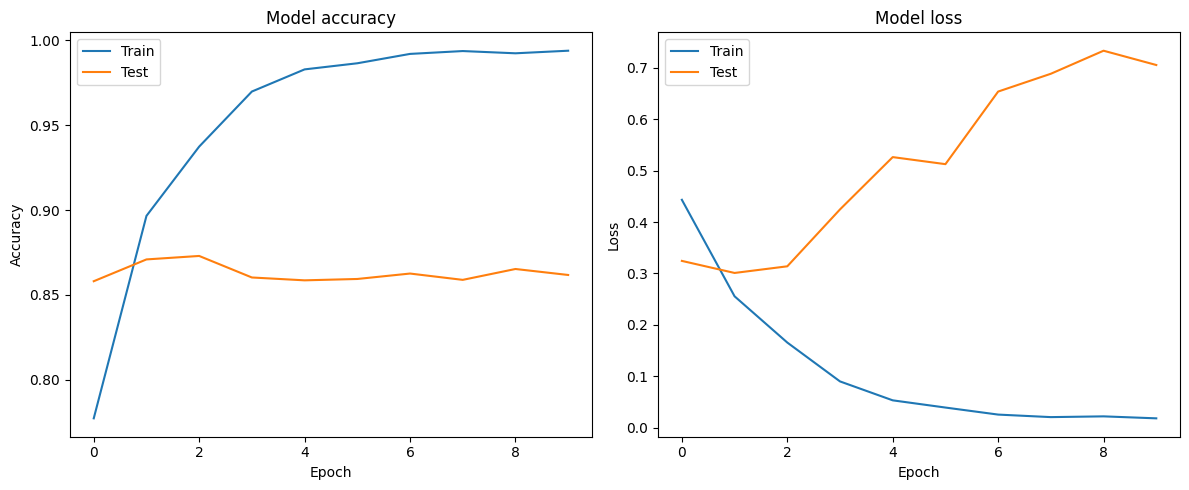

In [4]:
# Step 6: Train the model and capture the history
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))

# Step 7: Plot the accuracy and loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()